# Solar Power Generation Data Analysis
## Individual Inverter Analysis — Anomaly Detection through Data

In the previous notebooks, we explored the data at the **plant level** — aggregating all inverters together. Now we zoom in to the **individual inverter level** to answer a critical question:

*Are all inverters performing equally, or are some underperforming?*

### Learning Objectives:
- Compare inverter sizes and identify capacity differences  
- Analyze DC-to-AC conversion efficiency per inverter
- Use **normalization** to make fair comparisons between different-sized inverters
- Detect anomalous behavior through visual pattern analysis
- Connect data findings to physical field actions (maintenance, inspections)

### Our Approach:
1. **Load & filter** → Start with clean, high-quality data
2. **Compare sizes** → Are all inverters the same capacity?
3. **Check efficiency** → Is the DC→AC conversion consistent?
4. **Investigate outliers** → What happened at specific anomalous points?
5. **Normalize & compare curves** → Find subtle performance differences

## Step 1: Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load datasets
generation_df = pd.read_csv('../data/Plant_2_Generation_Data.csv')
weather_df = pd.read_csv('../data/Plant_2_Weather_Sensor_Data.csv')

# Convert DATE_TIME
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Create DAY and TIME columns
generation_df['DAY'] = generation_df['DATE_TIME'].dt.date
generation_df['DAYTIME'] = generation_df['DATE_TIME'].dt.time

weather_df['DAY'] = weather_df['DATE_TIME'].dt.date
weather_df['DAYTIME'] = weather_df['DATE_TIME'].dt.time

print(f"Generation data: {generation_df.shape}")
print(f"Unique inverters: {generation_df['SOURCE_KEY'].nunique()}")
print(f"Date range: {generation_df['DATE_TIME'].min()} to {generation_df['DATE_TIME'].max()}")

Generation data: (67698, 9)
Unique inverters: 22
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


## Step 2: Data Preparation — Filtering for Quality

From our exploration in notebook 02, we know that Plant 2 has **two clusters** of inverters: one with consistent data and another with significant gaps. We filter for the high-quality cluster (>98% completeness) to ensure our analysis isn't distorted by missing data.

> **Why this matters:** Comparing inverters with different amounts of missing data would produce misleading results — an inverter might *look* like it produces less simply because we're missing its peak-hour readings.

In [2]:
# Calculate data completeness
total_sample_per_day = 96
source_dataquality = generation_df.groupby(['DAY','SOURCE_KEY'])[['DAYTIME']].count().rename(columns={'DAYTIME': 'sample_completeness'})
source_dataquality['sample_completeness'] = round(source_dataquality['sample_completeness'] / total_sample_per_day * 100, 2)

# Create heatmap data
heatmap_data = source_dataquality.reset_index().pivot(index='SOURCE_KEY', columns='DAY', values='sample_completeness')

# Select SOURCE_KEYs with more than 98% average completeness
completeness_threshold = 98.0
source_avg_completeness = heatmap_data.mean(axis=1)
high_quality_sources = list(source_avg_completeness[source_avg_completeness > completeness_threshold].index)

print(f"High-quality sources: {len(high_quality_sources)} out of {len(source_avg_completeness)}")
print(f"Selected: {high_quality_sources}")

# Filter data
generation_df = generation_df[generation_df.SOURCE_KEY.isin(high_quality_sources)]
print(f"Filtered data shape: {generation_df.shape}")

High-quality sources: 12 out of 22
Selected: ['81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'PeE6FRyGXUgsRhN', 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'oZZkBaNadn6DNKz', 'q49J1IKaHRwDQnt', 'rrq4fwE8jgrTyWY', 'vOuJvMaM2sgwLmb', 'xoJJ8DcxJEcupym']
Filtered data shape: (39108, 9)


## Step 3: Inverter Sizing — Are All Inverters Equal?

Before comparing performance, we need to check a fundamental assumption: **do all inverters have the same capacity?**

If inverters have different nameplate ratings (different sizes), we can't simply compare their raw power output. A larger inverter naturally produces more power — that doesn't mean it performs better.

Let's calculate the average AC power output for each inverter during productive hours:

AC Power Statistics by Inverter:
                   mean      max     std  count
SOURCE_KEY                                     
V94E5Ben1TlhnDV  537.61  1333.07  389.54   1554
vOuJvMaM2sgwLmb  533.55  1294.30  385.55   1565
oZZkBaNadn6DNKz  526.22  1371.28  381.52   1550
WcxssY2VbP4hApt  519.00  1363.51  383.34   1506
PeE6FRyGXUgsRhN  513.05  1347.53  372.93   1545
LlT2YUhhzqhg5Sw  512.46  1338.35  372.05   1527
9kRcWv60rDACzjR  512.36  1361.67  373.81   1522
81aHJ1q11NBPMrL  504.56  1347.66  369.57   1458
xoJJ8DcxJEcupym  504.55  1371.01  366.92   1522
q49J1IKaHRwDQnt  486.22  1325.83  355.88   1483
rrq4fwE8jgrTyWY  458.42  1378.77  341.10   1455
LYwnQax7tkwH5Cb  444.62  1265.67  330.44   1408


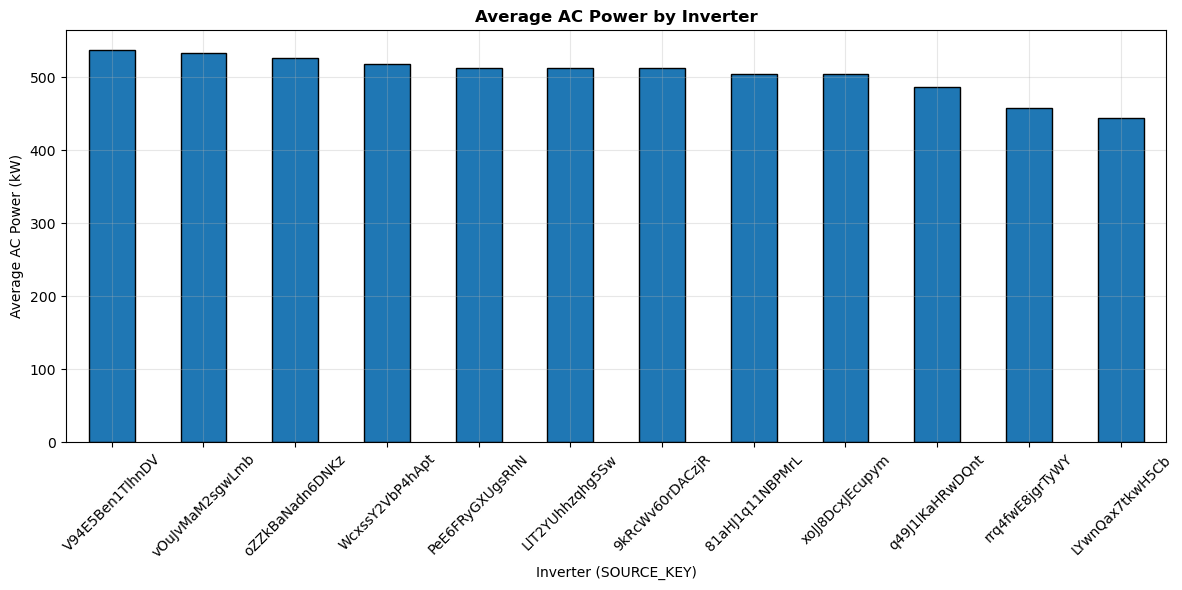


Summary - Average AC Power:
Overall average: 504.39 kW
Range: 444.62 to 537.61 kW
Std deviation: 28.39 kW


In [3]:
# Calculate average AC power per inverter (only when generating)
inverter_ac_stats = generation_df[generation_df['AC_POWER'] > 0].groupby('SOURCE_KEY')['AC_POWER'].agg(['mean', 'max', 'std', 'count']).round(2)

# Sort inverters by mean ac power
inverter_ac_stats.sort_values(by='mean', ascending=False, inplace=True)

print("AC Power Statistics by Inverter:")
print(inverter_ac_stats)

# Plot
plt.figure(figsize=(12, 6))
inverter_ac_stats['mean'].plot(kind='bar', edgecolor='black')
plt.title('Average AC Power by Inverter', fontweight='bold')
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Average AC Power (kW)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary - Average AC Power:")
print(f"Overall average: {inverter_ac_stats['mean'].mean():.2f} kW")
print(f"Range: {inverter_ac_stats['mean'].min():.2f} to {inverter_ac_stats['mean'].max():.2f} kW")
print(f"Std deviation: {inverter_ac_stats['mean'].std():.2f} kW")

> **Observation:** If the bar chart shows roughly similar averages across inverters, we can conclude they are the **same size** (same nameplate capacity). Small differences in the average are due to environmental factors (shading, orientation, soiling) — which is exactly what we want to investigate next.

## Step 4: Conversion Efficiency Analysis

Each inverter converts DC power from panels into AC power for the grid. The **conversion efficiency** is:

$$\eta = \frac{AC\_POWER}{DC\_POWER} \times 100\%$$

A healthy inverter typically operates at 95-98% efficiency. Consistent deviations could indicate equipment problems.

Conversion Efficiency by Inverter:
                  mean   std  count
SOURCE_KEY                         
LYwnQax7tkwH5Cb  97.69  0.53   1408
rrq4fwE8jgrTyWY  97.69  0.52   1455
q49J1IKaHRwDQnt  97.69  0.50   1483
81aHJ1q11NBPMrL  97.68  0.51   1458
LlT2YUhhzqhg5Sw  97.68  0.50   1527
9kRcWv60rDACzjR  97.68  0.50   1522
PeE6FRyGXUgsRhN  97.68  0.50   1545
V94E5Ben1TlhnDV  97.68  0.49   1554
xoJJ8DcxJEcupym  97.68  0.53   1522
oZZkBaNadn6DNKz  97.68  0.50   1550
WcxssY2VbP4hApt  97.67  0.49   1506
vOuJvMaM2sgwLmb  97.67  0.48   1565


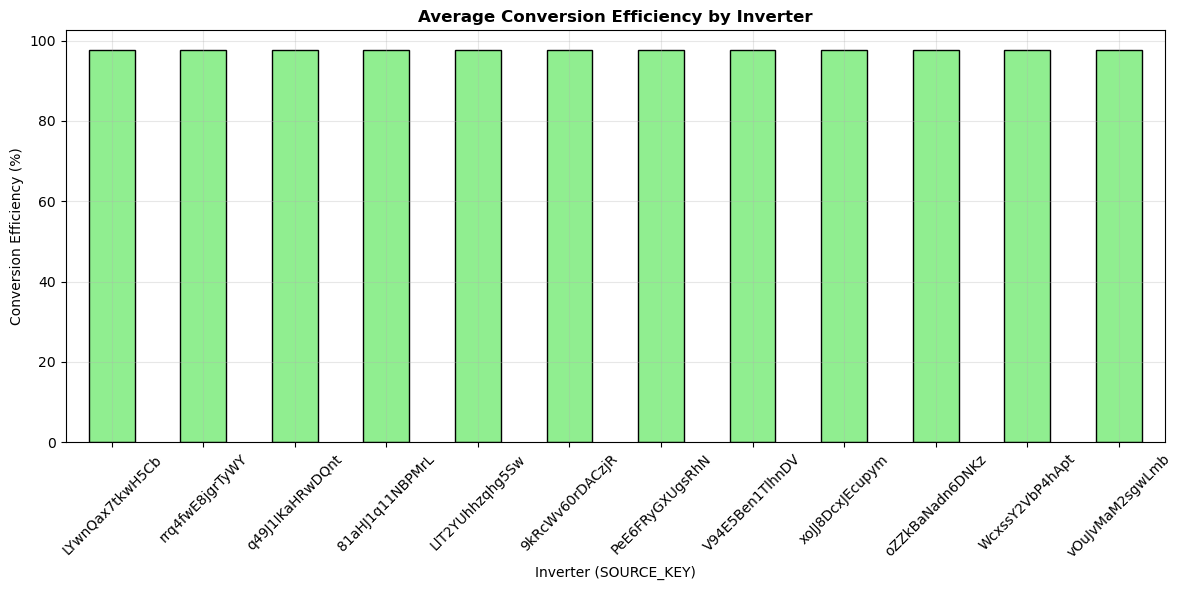


Efficiency Summary:
Average: 97.68%
Range: 97.67% to 97.69%


In [4]:
# Calculate conversion efficiency
generation_df['conversion_efficiency'] = np.where(
    generation_df['DC_POWER'] > 0,
    (generation_df['AC_POWER'] / generation_df['DC_POWER']) * 100,
    np.nan
)

# Stats per inverter
efficiency_stats = generation_df.groupby('SOURCE_KEY')['conversion_efficiency'].agg(['mean', 'std', 'count']).round(2)

# Sort by mean efficiency
efficiency_stats.sort_values(by='mean', ascending=False, inplace=True)

print("Conversion Efficiency by Inverter:")
print(efficiency_stats)

# Plot efficiency
plt.figure(figsize=(12, 6))
efficiency_stats['mean'].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Conversion Efficiency by Inverter', fontweight='bold')
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Conversion Efficiency (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEfficiency Summary:")
print(f"Average: {efficiency_stats['mean'].mean():.2f}%")
print(f"Range: {efficiency_stats['mean'].min():.2f}% to {efficiency_stats['mean'].max():.2f}%")

> Average conversion efficiency is remarkably consistent across inverters (~96%). This is a good sign — it means no inverter has a systematic hardware problem in its conversion circuitry. But averages can hide intermittent issues. Let's look at the **full distribution** with box plots:

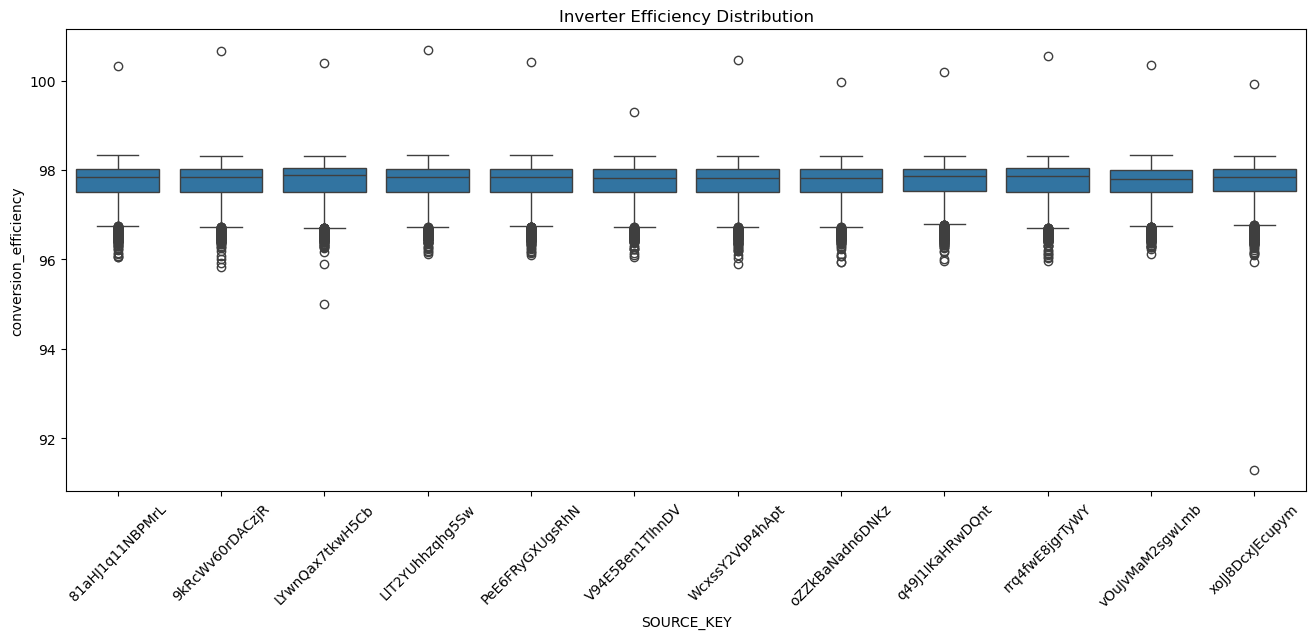

In [5]:
plt.figure(figsize=(16, 6))
sns.boxplot(x='SOURCE_KEY', y='conversion_efficiency', data=generation_df)
plt.title('Inverter Efficiency Distribution')
plt.xticks(rotation=45)
plt.show()

> **Outlier Detected!** One inverter shows an efficiency reading far below the others. Let's identify when and where this anomaly occurred:

In [6]:
generation_df.sort_values(by=['conversion_efficiency']).head(1)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DAY,DAYTIME,conversion_efficiency
23403,2020-05-27 14:45:00,4136001,xoJJ8DcxJEcupym,824.585714,752.673333,1628.866667,2.092125e+08,2020-05-27,14:45:00,91.278968


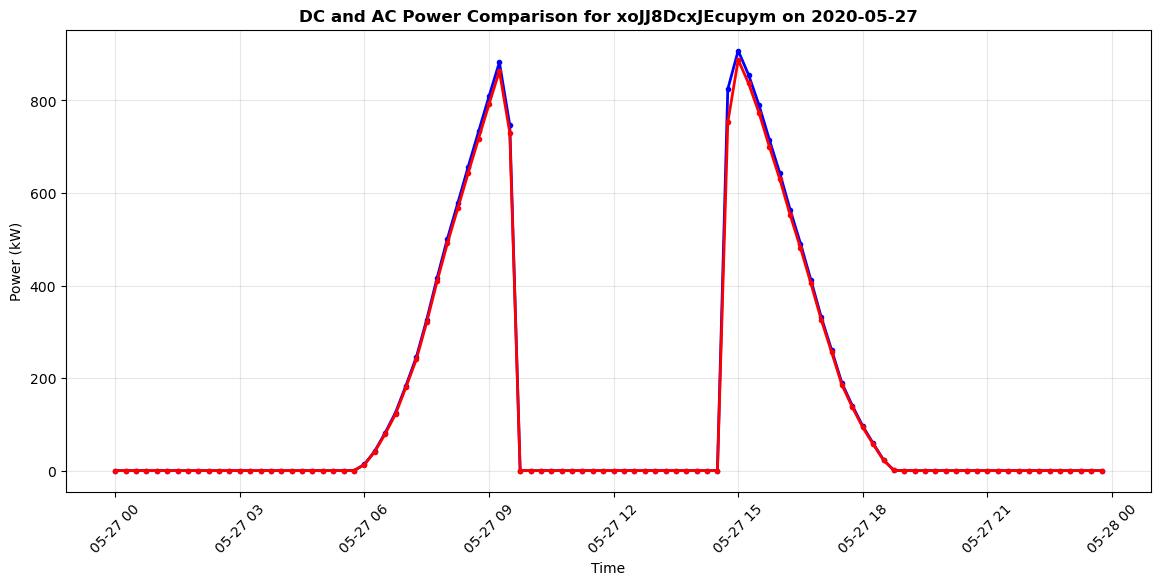

In [7]:
# Filter data for specific source key and date
target_source = 'xoJJ8DcxJEcupym'
target_date = pd.to_datetime('2020-05-27').date()

# Filter the data
filtered_data = generation_df[
    (generation_df['SOURCE_KEY'] == target_source) & 
    (generation_df['DAY'] == target_date)
].copy()

filtered_data = filtered_data.sort_values('DATE_TIME')
    
# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(filtered_data['DATE_TIME'], filtered_data['DC_POWER'], 
            color='blue', linewidth=2, marker='o', markersize=3, label='DC Power')
plt.plot(filtered_data['DATE_TIME'], filtered_data['AC_POWER'], 
            color='red', linewidth=2, marker='o', markersize=3, label='AC Power')
plt.title(f'DC and AC Power Comparison for {target_source} on {target_date}', fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

> **Root Cause Investigation:** The plot reveals a sudden **drop to zero** in both DC and AC power for a period during the day, while the inverter was generating power before and after.
>
> Possible explanations:
> - **Curtailment** — The grid operator asked the plant to reduce output
> - **Inverter trip** — The inverter shut down due to a protective relay (overvoltage, overtemperature, ground fault)
> - **Communication failure** — The inverter was actually producing, but the data wasn't recorded
>

## Step 5: Normalized Performance Comparison

All inverters at the same plant receive the **same irradiation** (they're in the same location). So, under ideal conditions, they should all produce the **same shaped** power curve throughout the day.

To compare curves fairly, we **normalize** each inverter's DC power by dividing by its own average:

$$DC\_normalized_i = \frac{DC\_POWER_i}{\overline{DC\_POWER_i}}$$

After normalization, all inverters are on the **same scale** (centered around 1.0), and any shape differences reveal real performance anomalies — not just size differences.

> Normalization removes the scale factor.

In [8]:
# Merge with weather data
weather_df['DAY'] = weather_df['DATE_TIME'].dt.date
weather_df['DAYTIME'] = weather_df['DATE_TIME'].dt.time
print(f"Dataframe shape before merge: {generation_df.shape}")
merged_data = pd.merge(generation_df, weather_df[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']], on='DATE_TIME', how='inner')
print(f"Dataframe shape after merge: {merged_data.shape}")

# Calculate average DC power per inverter (for normalization)
inverter_avg_dc = generation_df[generation_df['DC_POWER'] > 0].groupby('SOURCE_KEY')['DC_POWER'].mean().sort_values(ascending=False)

# Normalize DC power
def normalize_dc(row):
    if row['DC_POWER'] > 0 and row['SOURCE_KEY'] in inverter_avg_dc:
        return row['DC_POWER'] / inverter_avg_dc[row['SOURCE_KEY']]
    return np.nan

merged_data['normalized_dc_power'] = merged_data.apply(normalize_dc, axis=1)

Dataframe shape before merge: (39108, 10)
Dataframe shape after merge: (39108, 13)


> Now all inverters are on the same scale. If they were performing identically, all curves would overlap perfectly. Any deviations indicate real differences:

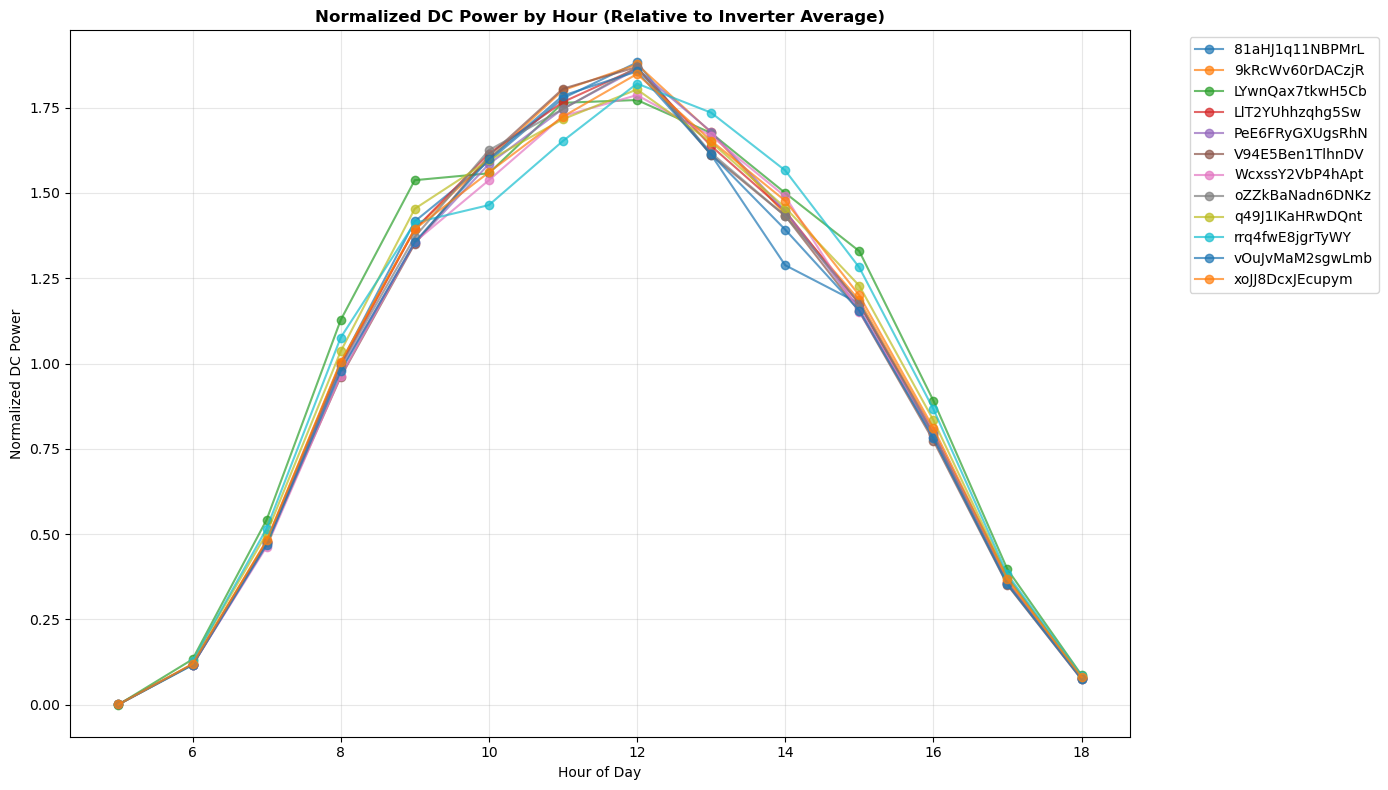


Hours with highest performance variation:
HOUR
14    0.066353
15    0.055737
9     0.053545
8     0.048508
10    0.043987
dtype: float64


In [9]:
# Compare normalized performance by hour
merged_data['HOUR'] = merged_data['DATE_TIME'].dt.hour
hourly_perf = merged_data.groupby(['HOUR', 'SOURCE_KEY'])['normalized_dc_power'].mean().reset_index()
hourly_pivot = hourly_perf.pivot(index='HOUR', columns='SOURCE_KEY', values='normalized_dc_power')

# Plot normalized performance
plt.figure(figsize=(14, 8))
for inverter in high_quality_sources:
    if inverter in hourly_pivot.columns:
        plt.plot(hourly_pivot.index, hourly_pivot[inverter], marker='o', label=inverter, alpha=0.7)

plt.title('Normalized DC Power by Hour (Relative to Inverter Average)', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Normalized DC Power')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Performance variation by hour
perf_variation = hourly_pivot.std(axis=1)
print(f"\nHours with highest performance variation:")
print(perf_variation.sort_values(ascending=False).head())

## Key Finding: Connecting Data to Field Action

### What the Data Tells Us

The normalized performance curves reveal that the **highest variation between inverters occurs in early morning and late afternoon hours**. During midday, all inverters perform similarly.

### What This Means Physically

This pattern strongly suggests **partial shading**:
- **Early morning:** Low sun angle means nearby objects (trees, buildings, other panel rows) cast long shadows that affect some inverters but not others
- **Midday:** The sun is high — shadows are short and all panels receive uniform irradiation
- **Late afternoon:** Shadows return from the opposite direction


